In [1]:
from pyspark.sql import SparkSession

# Initialize SparkSession
spark = SparkSession.builder.appName("IntrusionDetection").getOrCreate()

# List of CSV files to load from Google Drive
csv_files = [
    "/content/drive/MyDrive/folder new/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "/content/drive/MyDrive/folder new/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "/content/drive/MyDrive/folder new/Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "/content/drive/MyDrive/folder new/Monday-WorkingHours.pcap_ISCX.csv",
    "/content/drive/MyDrive/folder new/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "/content/drive/MyDrive/folder new/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "/content/drive/MyDrive/folder new/Wednesday-workingHours.pcap_ISCX.csv",
    "/content/drive/MyDrive/folder new/Tuesday-WorkingHours.pcap_ISCX.csv"
]

# Read all CSV files into a single DataFrame
# Use inferSchema and header options
try:
    combined_df = spark.read.csv(csv_files, header=True, inferSchema=True)
    print("Combined DataFrame created successfully.")
    print("Combined shape (number of rows):", combined_df.count())
    print("Combined DataFrame schema:")
    combined_df.printSchema()
except Exception as e:
    print(f"Error loading or combining CSV files: {e}")

Combined DataFrame created successfully.
Combined shape (number of rows): 2830743
Combined DataFrame schema:
root
 |--  Destination Port: integer (nullable = true)
 |--  Flow Duration: integer (nullable = true)
 |--  Total Fwd Packets: integer (nullable = true)
 |--  Total Backward Packets: integer (nullable = true)
 |-- Total Length of Fwd Packets: integer (nullable = true)
 |--  Total Length of Bwd Packets: integer (nullable = true)
 |--  Fwd Packet Length Max: integer (nullable = true)
 |--  Fwd Packet Length Min: integer (nullable = true)
 |--  Fwd Packet Length Mean: double (nullable = true)
 |--  Fwd Packet Length Std: double (nullable = true)
 |-- Bwd Packet Length Max: integer (nullable = true)
 |--  Bwd Packet Length Min: integer (nullable = true)
 |--  Bwd Packet Length Mean: double (nullable = true)
 |--  Bwd Packet Length Std: double (nullable = true)
 |-- Flow Bytes/s: double (nullable = true)
 |--  Flow Packets/s: double (nullable = true)
 |--  Flow IAT Mean: double (null

In [2]:
from pyspark.sql.functions import col, trim, when

# Strip whitespace from column names
# PySpark DataFrames are immutable, so we create a new DataFrame with cleaned column names
cleaned_df = combined_df
for col_name in combined_df.columns:
    cleaned_df = cleaned_df.withColumnRenamed(col_name, col_name.strip())

# Strip whitespace from the 'Label' column
cleaned_df = cleaned_df.withColumn("Label", trim(col("Label")))

# Define the mapping for labels
# In PySpark, we can use the `when` function for conditional mapping
mapping = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'PortScan': 'PortScan',
    'DoS GoldenEye': 'DoS',
    'DoS Hulk': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'DoS slowloris': 'DoS'
}

# Create the 'Label_grp' column using the mapping
# We'll use a series of when().otherwise() for the mapping
label_grp_col = when(col("Label") == "BENIGN", "BENIGN") \
    .when(col("Label") == "DDoS", "DDoS") \
    .when(col("Label") == "PortScan", "PortScan") \
    .when(col("Label") == "DoS GoldenEye", "DoS") \
    .when(col("Label") == "DoS Hulk", "DoS") \
    .when(col("Label") == "DoS Slowhttptest", "DoS") \
    .when(col("Label") == "DoS slowloris", "DoS") \
    .otherwise("Other")

cleaned_df = cleaned_df.withColumn("Label_grp", label_grp_col)

# Display the new class counts
print("New class counts:")
cleaned_df.groupBy("Label_grp").count().show()

# Update combined_df to the cleaned version for subsequent steps
combined_df = cleaned_df

New class counts:
+---------+-------+
|Label_grp|  count|
+---------+-------+
|   BENIGN|2273097|
|      DoS| 252661|
|    Other|  18028|
|     DDoS| 128027|
| PortScan| 158930|
+---------+-------+



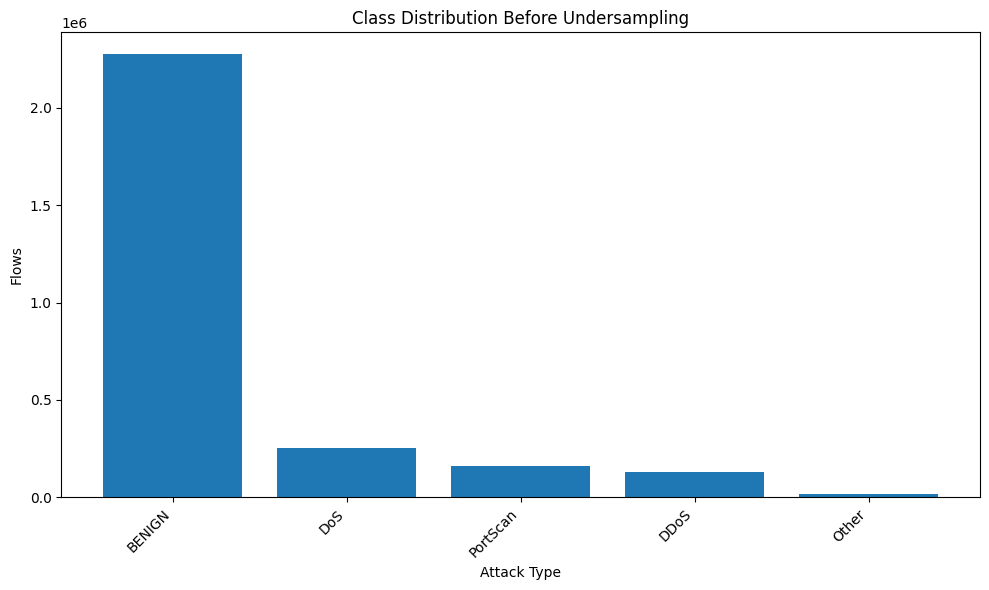

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the counts of the 'Label_grp' column from the PySpark DataFrame before undersampling
label_grp_counts_spark_before = cleaned_df.groupBy("Label_grp").count()

# Convert the PySpark DataFrame to a pandas DataFrame for plotting
label_grp_counts_pandas_before = label_grp_counts_spark_before.toPandas()

# Sort the pandas DataFrame by count for better visualization
label_grp_counts_pandas_before = label_grp_counts_pandas_before.sort_values(by="count", ascending=False)

# Create the bar plot for the class distribution before undersampling
plt.figure(figsize=(10, 6))
plt.bar(label_grp_counts_pandas_before["Label_grp"], label_grp_counts_pandas_before["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution Before Undersampling")
plt.ylabel("Flows")
plt.xlabel("Attack Type")
plt.tight_layout()
plt.show()

In [4]:
from pyspark.sql.functions import col
from pyspark.sql import DataFrame

# Define the maximum number of samples for each class
max_samples = 50000

# Get the counts for each class
class_counts = combined_df.groupBy("Label_grp").count()

# Create a list to hold the sampled DataFrames
sampled_dfs = []

# Iterate over each class and its count
for row in class_counts.collect():
    class_name = row["Label_grp"]
    count = row["count"]

    if count > max_samples:
        # If the class count is greater than max_samples, sample the DataFrame
        # The sample method in PySpark takes a fraction, so we need to calculate it
        fraction = max_samples / count
        # Use sample(withReplacement, fraction, seed)
        # We'll use False for withReplacement and a fixed seed for reproducibility
        sampled_df = combined_df.filter(col("Label_grp") == class_name).sample(False, fraction, 42)
        sampled_dfs.append(sampled_df)
    else:
        # If the class count is less than or equal to max_samples, include all samples for that class
        sampled_dfs.append(combined_df.filter(col("Label_grp") == class_name))

# Union all the sampled DataFrames
# Ensure there are DataFrames to union
if sampled_dfs:
    df_bal = sampled_dfs[0]
    for i in range(1, len(sampled_dfs)):
        df_bal = df_bal.unionAll(sampled_dfs[i])

    print("After undersampling:")
    df_bal.groupBy("Label_grp").count().show()
else:
    print("No data to sample.")

# Update combined_df to the balanced version for subsequent steps
combined_df = df_bal

After undersampling:
+---------+-----+
|Label_grp|count|
+---------+-----+
|   BENIGN|50095|
|      DoS|50377|
|    Other|18028|
|     DDoS|50218|
| PortScan|50402|
+---------+-----+



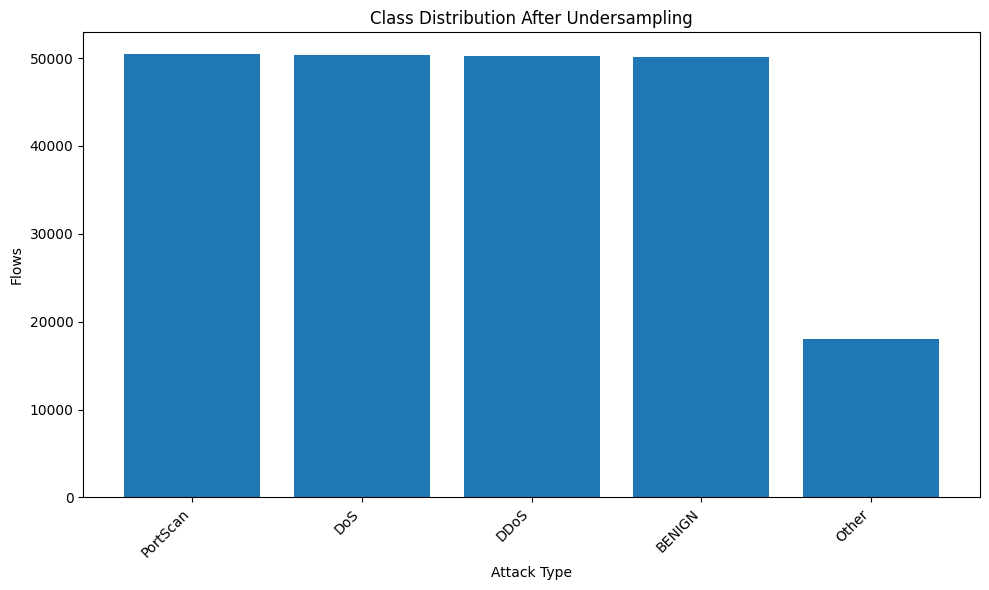

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the counts of the 'Label_grp' column from the PySpark DataFrame after undersampling
label_grp_counts_spark_after = df_bal.groupBy("Label_grp").count()

# Convert the PySpark DataFrame to a pandas DataFrame for plotting
label_grp_counts_pandas_after = label_grp_counts_spark_after.toPandas()

# Sort the pandas DataFrame by count for better visualization
label_grp_counts_pandas_after = label_grp_counts_pandas_after.sort_values(by="count", ascending=False)

# Create the bar plot for the class distribution after undersampling
plt.figure(figsize=(10, 6))
plt.bar(label_grp_counts_pandas_after["Label_grp"], label_grp_counts_pandas_after["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution After Undersampling")
plt.ylabel("Flows")
plt.xlabel("Attack Type")
plt.tight_layout()
plt.show()

In [8]:
# Split data into training and testing sets
# We'll use the requested 80% for training and 20% for testing
# Use a seed for reproducibility
# Make sure to split the DataFrame that contains the 'features' and 'label_index' columns (which is currently combined_df)
training_data, testing_data = combined_df.randomSplit([0.8, 0.2], seed=42)

print("Training data count:", training_data.count())
print("Testing data count:", testing_data.count())

Training data count: 175327
Testing data count: 43793


In [17]:
# Assuming there is a ' Source IP' column in the original data.
# Let's first check if a column related to source IP exists in the current DataFrame schema.
print("Schema of combined_df:")
combined_df.printSchema()

# Based on the schema, there is no ' Source IP' column after feature selection.
# We cannot analyze source IP information with the current DataFrame.
# If source IP analysis is required, we would need to go back to the original DataFrame
# before feature selection or ensure the source IP column is included.

print("\nNo source IP column found in the current DataFrame for source analysis.")
print("To analyze source IPs, the column needs to be retained during feature selection.")

Schema of combined_df:
root
 |-- Destination Port: integer (nullable = true)
 |-- Flow Duration: integer (nullable = true)
 |-- Total Fwd Packets: integer (nullable = true)
 |-- Total Backward Packets: integer (nullable = true)
 |-- Total Length of Fwd Packets: integer (nullable = true)
 |-- Total Length of Bwd Packets: integer (nullable = true)
 |-- Fwd Packet Length Max: integer (nullable = true)
 |-- Fwd Packet Length Min: integer (nullable = true)
 |-- Fwd Packet Length Mean: double (nullable = true)
 |-- Fwd Packet Length Std: double (nullable = true)
 |-- Bwd Packet Length Max: integer (nullable = true)
 |-- Bwd Packet Length Min: integer (nullable = true)
 |-- Bwd Packet Length Mean: double (nullable = true)
 |-- Bwd Packet Length Std: double (nullable = true)
 |-- Flow Bytes/s: double (nullable = true)
 |-- Flow Packets/s: double (nullable = true)
 |-- Flow IAT Mean: double (nullable = true)
 |-- Flow IAT Std: double (nullable = true)
 |-- Flow IAT Max: integer (nullable = true

In [18]:
from pyspark.sql.types import DoubleType, IntegerType, LongType

# Identify numerical columns based on the schema, excluding 'Label' and 'Label_grp'
numerical_cols = [field.name for field in combined_df.schema.fields
                  if isinstance(field.dataType, (DoubleType, IntegerType, LongType)) and field.name not in ['Label', 'Label_grp']]

# Identify non-numerical columns that are not the target variable
non_numerical_cols_to_drop = [field.name for field in combined_df.schema.fields
                              if not isinstance(field.dataType, (DoubleType, IntegerType, LongType)) and field.name not in ['Label', 'Label_grp']]

print("Numerical columns identified:", numerical_cols)
print("Non-numerical columns to drop:", non_numerical_cols_to_drop)

# Drop the identified non-numerical columns
# Keep 'Label_grp' and the numerical columns
columns_to_keep = numerical_cols + ['Label_grp']
cleaned_df = combined_df.select(columns_to_keep)

# Inspect the schema of the cleaned DataFrame
print("\nSchema after dropping non-numerical columns:")
cleaned_df.printSchema()

# Show a sample of the cleaned DataFrame
print("\nSample of the cleaned DataFrame:")
cleaned_df.limit(5).show()

# Update combined_df to the cleaned version
combined_df = cleaned_df

Numerical columns identified: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length34', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', '

In [20]:
from pyspark.ml.feature import VectorAssembler, MinMaxScaler, StringIndexer
from pyspark.sql.types import DoubleType, IntegerType, LongType
from pyspark.sql.functions import col

# 1. Identify the numerical feature columns from the combined_df DataFrame.
# Exclude the 'Label_grp' column.
numerical_cols = [field.name for field in combined_df.schema.fields
                  if isinstance(field.dataType, (DoubleType, IntegerType, LongType)) and field.name != 'Label_grp']

# Handle NaN values in numerical columns by filling with 0
filled_df = combined_df.na.fill(0, subset=numerical_cols)

# 3. Create a VectorAssembler to combine the numerical feature columns into a single vector column named 'numerical_features'.
assembler = VectorAssembler(inputCols=numerical_cols, outputCol="numerical_features")

# 4. Apply the VectorAssembler to the filled_df DataFrame to create the 'numerical_features' column.
combined_df_assembled = assembler.transform(filled_df)

# 5. Create a MinMaxScaler to scale the 'numerical_features' vector column to a range of [0, 1]. Fit the scaler to the DataFrame.
scaler = MinMaxScaler(inputCol="numerical_features", outputCol="scaled_features")
scaler_model = scaler.fit(combined_df_assembled)

# 6. Apply the fitted MinMaxScaler to the DataFrame to create the 'scaled_features' column.
combined_df_scaled = scaler_model.transform(combined_df_assembled)

# 7. Create a StringIndexer to convert the 'Label_grp' categorical column into a numerical index column named 'label_index'. Fit the indexer to the DataFrame.
indexer = StringIndexer(inputCol="Label_grp", outputCol="label_index")
indexer_model = indexer.fit(combined_df_scaled)

# 8. Apply the fitted StringIndexer to the DataFrame to create the 'label_index' column.
combined_df_indexed = indexer_model.transform(combined_df_scaled)

# 9. Select the 'scaled_features' and 'label_index' columns, renaming 'scaled_features' to 'features' for consistency with typical ML model input.
final_df = combined_df_indexed.select(col("scaled_features").alias("features"), col("label_index"))

# Re-split the final_df into training and testing sets
training_data, testing_data = final_df.randomSplit([0.8, 0.2], seed=42)


print("Prepared DataFrame schema:")
final_df.printSchema()
print("Sample of prepared DataFrame:")
final_df.limit(5).show(truncate=False)

print("Training data count:", training_data.count())
print("Testing data count:", testing_data.count())

Prepared DataFrame schema:
root
 |-- features: vector (nullable = true)
 |-- label_index: double (nullable = false)

Sample of prepared DataFrame:
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [22]:
from pyspark.ml.classification import RandomForestClassifier

# Instantiate a RandomForestClassifier model
rf = RandomForestClassifier(featuresCol="features", labelCol="label_index", numTrees=100)

# Fit the model to the training data
rf_model = rf.fit(training_data)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [21]:
from pyspark.ml.classification import LogisticRegression

# Instantiate a LogisticRegression model
lr = LogisticRegression(featuresCol="features", labelCol="label_index")

# Fit the model to the training data
lr_model = lr.fit(training_data)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [26]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Use the trained logistic regression model (lr_model) to make predictions on the testing_data DataFrame.
lr_predictions = lr_model.transform(testing_data)

# Instantiate the MulticlassClassificationEvaluator for accuracy for Logistic Regression.
lr_accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label_index", predictionCol="prediction", metricName="accuracy")

# Evaluate the accuracy of the Logistic Regression model.
lr_accuracy = lr_accuracy_evaluator.evaluate(lr_predictions)

# Print the calculated accuracy for Logistic Regression.
print(f"Logistic Regression Accuracy: {lr_accuracy}")

# Instantiate the MulticlassClassificationEvaluator for F1-score for Logistic Regression.
lr_f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label_index", predictionCol="prediction", metricName="f1")

# Evaluate the F1-score of the Logistic Regression model.
lr_f1_score = lr_f1_evaluator.evaluate(lr_predictions)

# Print the calculated F1-score for Logistic Regression.
print(f"Logistic Regression F1-score: {lr_f1_score}")

Logistic Regression Accuracy: 0.9600392756833284
Logistic Regression F1-score: 0.9596415931826181


In [27]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Use the trained random forest model (rf_model) to make predictions on the testing_data DataFrame.
rf_predictions = rf_model.transform(testing_data)

# Instantiate the MulticlassClassificationEvaluator for accuracy for Random Forest.
rf_accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label_index", predictionCol="prediction", metricName="accuracy")

# Evaluate the accuracy of the Random Forest model.
rf_accuracy = rf_accuracy_evaluator.evaluate(rf_predictions)

# Print the calculated accuracy for Random Forest.
print(f"Random Forest Accuracy: {rf_accuracy}")

# Instantiate the MulticlassClassificationEvaluator for F1-score for Random Forest.
rf_f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label_index", predictionCol="prediction", metricName="f1")

# Evaluate the F1-score of the Random Forest model.
rf_f1_score = rf_f1_evaluator.evaluate(rf_predictions)

# Print the calculated F1-score for Random Forest.
print(f"Random Forest F1-score: {rf_f1_score}")

Random Forest Accuracy: 0.9743794670381111
Random Forest F1-score: 0.9743258370609658
